## 9. Make Theta
Make phase, for all cc derived theta or from MUA

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import neo
from elephant.conversion import BinnedSpikeTrain

In [3]:
import os
import elephant
import quantities as pq
import numpy as np
import xarray as xr
import neo
from elephant.conversion import BinnedSpikeTrain
from spyglass.spikesorting.v0.spikesorting_curation import WaveformParameters, WaveformSelection, Waveforms
import pandas as pd
from spyglass.spikesorting.v0.spikesorting_curation import QualityMetrics
from spyglass.shijiegu.singleUnit import electrode_unit
import matplotlib.pyplot as plt
from spyglass.shijiegu.Analysis_SGU import SingleUnit, MUATheta, TetrodeNumber, TrialChoice
from spyglass.shijiegu.theta_singleUnit import mua_pyramidal_only, get_theta_from_cc, get_theta_from_mua, smoothen_mua
from spyglass.shijiegu.load import load_run_sessions, load_theta
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.theta_mua import calculate_session_theta_from_mua

[2026-03-07 13:38:42,762][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [30]:
from spyglass.shijiegu.Analysis_SGU import SingleUnit, MUAThetaNWB, ThetaZscore

In [31]:
from spyglass.shijiegu.theta_singleUnit import make_phase_from_amplitude
from spyglass.shijiegu.Analysis_nwb_helper import write_data_to_analyis_nwb



def get_mua_theta(nwb_copy_file_name,session_name):
    theta = calculate_session_theta_from_mua(nwb_copy_file_name, session_name)
    return theta

In [80]:
dates_to_plot_animals = {}
success_animals = {}

animal = 'eliot'
dates_to_plot_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'molly'
dates_to_plot_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
dates_to_plot_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']

animal = "julio"
dates_to_plot_animals[animal] = ['20230731']#,'20230801','20230802','20230803','20230804',
                 #'20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = "klein"
dates_to_plot_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']

In [81]:
theta_type = 'cc'

In [84]:
# Every session processed theta is saved to both tables, MUATheta and MUAThetaNWB:
# MUATheta's "theta_xr" field saves a cvs address to read the theta pd Dataframe.
# MUAThetaNWB is linked to AnalysisNWB.
outputfolder = '/cumulus/shijie/recording_pilot/theta/'


for animal in ["julio"]:#dates_to_plot_animals.keys():
    if animal == "lewis":
        datafield = 'rightside'
    else:
        datafield = 'leftside'
    for d in dates_to_plot_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:

            if theta_type == 'cc':
                theta_xr = get_theta_from_cc(nwb_copy_file_name,session_name,datafield=datafield)
                theta_suffix = 'cctheta'
                label = "corpus_callosum"
            elif theta_type == 'mua':
                theta_xr = get_mua_theta(nwb_copy_file_name,session_name)
                theta_suffix = 'muatheta'
                label = "mua"
    
            # save xr to path
            theta_df = theta_xr.to_pandas()

            #insert entry into Spyglass
            data = {"time":np.array(theta_df.index), "amplitude":np.array(theta_df.amplitude), "phase":np.array(theta_df.phase)}

            key = write_data_to_analyis_nwb(data, "theta", nwb_copy_file_name, MUAThetaNWB().full_table_name)

            # insert entry into Spyglass
            key["epoch"] = str(session_name[:2])
            key["data_type"] = label

            MUAThetaNWB().insert1(key,replace = True)

            # write to MUATheta
            filename = f"{nwb_copy_file_name}_{session_name}_{theta_suffix}.csv"
            filename = os.path.join(outputfolder,filename)
            key = {"nwb_file_name": nwb_copy_file_name, "theta_xr": filename}
            key["epoch"] = str(session_name[:2])
            key["data_type"] = label
            theta_df.to_csv(filename)
            
            MUATheta().insert1(key,replace = True)
            

            success_animals[(animal, d, session_name)] = True
           # except:
           #     success_animals[(animal, d, session_name)] = False


[2026-03-15 14:19:24,706][WARNING]: Skipped checksum for file with hash: e85c74c5-0096-c3fa-9443-05d1ecdef5d2, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_K4ABVDHLJX.nwb
[2026-03-15 14:19:24,720][WARNING]: Skipped checksum for file with hash: e85c74c5-0096-c3fa-9443-05d1ecdef5d2, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_K4ABVDHLJX.nwb
[2026-03-15 14:19:24,730][WARNING]: Skipped checksum for file with hash: e85c74c5-0096-c3fa-9443-05d1ecdef5d2, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_K4ABVDHLJX.nwb
[2026-03-15 14:19:24,737][WARNING]: Skipped checksum for file with hash: e85c74c5-0096-c3fa-9443-05d1ecdef5d2, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_K4ABVDHLJX.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
julio20230731_ 1         01_Seq2Sleep1  pos 0 valid ti
julio20230731_ 2         02_Seq2Session pos 1 valid ti
julio20230731_ 3         03_Seq2Sleep2  pos 2 valid ti
julio20230731_ 4         04_Seq2Session pos 3 valid ti
julio20230731_ 5         05_Seq2Sleep3  pos 4 valid ti
julio20230731_ 6         06_Seq2Session pos 5 valid ti
julio20230731_ 7         07_Seq2Sleep4  pos 6 valid ti
julio20230731_ 8         08_Seq2Session pos 7 valid ti
julio20230731_ 9         09_Seq2Sleep5  pos 8 valid ti
julio20230731_ 10        10_Seq2Session pos 9 valid ti
julio20230731_ 11        11_Seq2Sleep6  pos 10 valid t
julio20230731_ 12        12_Seq2Session pos 11 valid t
   ...
 (Total: 13)

len(peak_ind) 18323


[14:19:52][INFO] Spyglass: Writing new NWB file julio20230731_16ZI5PUM48.nwb
INFO:spyglass:Writing new NWB file julio20230731_16ZI5PUM48.nwb
[2026-03-15 14:20:35,616][WARNING]: Skipped checksum for file with hash: ae4b514f-949c-0c28-d5da-6c3f6e6aae60, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_A8WMPUCQ3Z.nwb
[2026-03-15 14:20:35,631][WARNING]: Skipped checksum for file with hash: ae4b514f-949c-0c28-d5da-6c3f6e6aae60, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_A8WMPUCQ3Z.nwb
[2026-03-15 14:20:35,644][WARNING]: Skipped checksum for file with hash: ae4b514f-949c-0c28-d5da-6c3f6e6aae60, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_A8WMPUCQ3Z.nwb
[2026-03-15 14:20:35,653][WARNING]: Skipped checksum for file with hash: ae4b514f-949c-0c28-d5da-6c3f6e6aae60, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_A8WMPUCQ3Z.nwb


len(peak_ind) 19918


[14:21:14][INFO] Spyglass: Writing new NWB file julio20230731_64VVY5JLUY.nwb
INFO:spyglass:Writing new NWB file julio20230731_64VVY5JLUY.nwb
[2026-03-15 14:21:59,880][WARNING]: Skipped checksum for file with hash: 5d2fc94f-4be8-7e78-4f5b-fa202752d0c6, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_RD998W64O9.nwb
[2026-03-15 14:21:59,895][WARNING]: Skipped checksum for file with hash: 5d2fc94f-4be8-7e78-4f5b-fa202752d0c6, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_RD998W64O9.nwb
[2026-03-15 14:21:59,907][WARNING]: Skipped checksum for file with hash: 5d2fc94f-4be8-7e78-4f5b-fa202752d0c6, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_RD998W64O9.nwb
[2026-03-15 14:21:59,917][WARNING]: Skipped checksum for file with hash: 5d2fc94f-4be8-7e78-4f5b-fa202752d0c6, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_RD998W64O9.nwb


...

[14:23:51][INFO] Spyglass: Writing new NWB file julio20230731_7M2K2DJWIA.nwb
INFO:spyglass:Writing new NWB file julio20230731_7M2K2DJWIA.nwb
[2026-03-15 14:24:32,352][WARNING]: Skipped checksum for file with hash: aca410e4-002c-42dc-f8ee-4c1fb4611062, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2OKJXYFMBU.nwb
[2026-03-15 14:24:32,361][WARNING]: Skipped checksum for file with hash: aca410e4-002c-42dc-f8ee-4c1fb4611062, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2OKJXYFMBU.nwb
[2026-03-15 14:24:32,369][WARNING]: Skipped checksum for file with hash: aca410e4-002c-42dc-f8ee-4c1fb4611062, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2OKJXYFMBU.nwb
[2026-03-15 14:24:32,374][WARNING]: Skipped checksum for file with hash: aca410e4-002c-42dc-f8ee-4c1fb4611062, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2OKJXYFMBU.nwb


len(peak_ind) 18696


[14:25:11][INFO] Spyglass: Writing new NWB file julio20230731_SV2WPUPX46.nwb
INFO:spyglass:Writing new NWB file julio20230731_SV2WPUPX46.nwb
[2026-03-15 14:25:51,745][WARNING]: Skipped checksum for file with hash: 2e9a10db-7ba8-2031-2bae-62e421c16af1, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_BHVLEI9F04.nwb
[2026-03-15 14:25:51,757][WARNING]: Skipped checksum for file with hash: 2e9a10db-7ba8-2031-2bae-62e421c16af1, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_BHVLEI9F04.nwb
[2026-03-15 14:25:51,766][WARNING]: Skipped checksum for file with hash: 2e9a10db-7ba8-2031-2bae-62e421c16af1, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_BHVLEI9F04.nwb
[2026-03-15 14:25:51,772][WARNING]: Skipped checksum for file with hash: 2e9a10db-7ba8-2031-2bae-62e421c16af1, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_BHVLEI9F04.nwb


len(peak_ind) 20907


[14:26:32][INFO] Spyglass: Writing new NWB file julio20230731_605DIYBDCU.nwb
INFO:spyglass:Writing new NWB file julio20230731_605DIYBDCU.nwb


In [83]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/fetch.py(332)__call__()
    330             )
    331             if len(result) != 1:
--> 332                 raise DataJointError(
    333                     "fetch1 should only return one tuple. %d tuples found" % len(result)
    334                 )



ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/theta_singleUnit.py(219)get_theta_from_cc()
    217 
    218     CCTetrodeInd = (TetrodeNumber() & {'nwb_file_name': nwb_copy_file_name,
--> 219                                             'epoch':session_name[:2]}).fetch1('cc_tetrode_ind')
    220 
    221     if len(CCTetrodeInd) == 1:



ipdb>  TetrodeNumber() & {'nwb_file_name': nwb_copy_file_name}


*nwb_file_name *epoch    epoch_name     ca1_tetrod cc_tetrode
+------------+ +-------+ +------------+ +--------+ +--------+

 (Total: 0)



ipdb>  exit


In [85]:
success_animals

{('julio', '20230731', '02_Seq2Session1'): True,
 ('julio', '20230731', '04_Seq2Session2'): True,
 ('julio', '20230731', '06_Seq2Session3'): True,
 ('julio', '20230731', '08_Seq2Session4'): True,
 ('julio', '20230731', '10_Seq2Session5'): True,
 ('julio', '20230731', '12_Seq2Session6'): True}

### Zscore theta

In [86]:
from spyglass.shijiegu.theta_singleUnit import zscore_theta, zscore_theta_animal

In [74]:
nwb_copy_file_name = 'molly20220419_.nwb'
session_name = "06_Seq2Session3"

theta_pd, mean, sd = zscore_theta(nwb_copy_file_name,session_name,
                        "corpus_callosum",use_spyglass = False)

[2026-03-10 19:56:51,811][WARNING]: Skipped checksum for file with hash: ada77bca-0080-f3d4-bddd-1f4dfdaeb2b7, and path: /stelmo/nwb/analysis/molly20220419_4T2L4AA81B.nwb
[2026-03-10 19:56:51,820][WARNING]: Skipped checksum for file with hash: ada77bca-0080-f3d4-bddd-1f4dfdaeb2b7, and path: /stelmo/nwb/analysis/molly20220419_4T2L4AA81B.nwb
[2026-03-10 19:56:51,827][WARNING]: Skipped checksum for file with hash: ada77bca-0080-f3d4-bddd-1f4dfdaeb2b7, and path: /stelmo/nwb/analysis/molly20220419_4T2L4AA81B.nwb
[2026-03-10 19:56:51,832][WARNING]: Skipped checksum for file with hash: ada77bca-0080-f3d4-bddd-1f4dfdaeb2b7, and path: /stelmo/nwb/analysis/molly20220419_4T2L4AA81B.nwb


before speed thresholding: length of 1985555 33 min of recording
after speed thresholding: length of 902879 15 min of recording


32.05780633687973

In [88]:
for animal in ["julio"]:
    success = zscore_theta_animal(animal, dates_to_plot_animals[animal],
                              "corpus_callosum", use_spyglass = False)      

[2026-03-15 14:31:24,497][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-03-15 14:31:24,507][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-03-15 14:31:24,518][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-03-15 14:31:24,525][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb


before speed thresholding: length of 2584963 7 min of recording
after speed thresholding: length of 1053120 2 min of recording


[2026-03-15 14:31:35,758][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-03-15 14:31:35,768][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-03-15 14:31:35,779][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-03-15 14:31:35,786][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb


before speed thresholding: length of 2782251 6 min of recording
after speed thresholding: length of 1109403 2 min of recording


[2026-03-15 14:31:48,561][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-03-15 14:31:48,573][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-03-15 14:31:48,584][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-03-15 14:31:48,591][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb


...

before speed thresholding: length of 2610292 13 min of recording
after speed thresholding: length of 1044206 5 min of recording


[2026-03-15 14:32:14,940][WARNING]: Skipped checksum for file with hash: f6799e22-5094-1ec8-169a-fae68460ef91, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2M62ZUR122.nwb
[2026-03-15 14:32:14,950][WARNING]: Skipped checksum for file with hash: f6799e22-5094-1ec8-169a-fae68460ef91, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2M62ZUR122.nwb
[2026-03-15 14:32:14,961][WARNING]: Skipped checksum for file with hash: f6799e22-5094-1ec8-169a-fae68460ef91, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2M62ZUR122.nwb
[2026-03-15 14:32:14,967][WARNING]: Skipped checksum for file with hash: f6799e22-5094-1ec8-169a-fae68460ef91, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_2M62ZUR122.nwb


before speed thresholding: length of 2569980 8 min of recording
after speed thresholding: length of 1115413 3 min of recording


[2026-03-15 14:32:28,811][WARNING]: Skipped checksum for file with hash: ba2309ed-4968-c749-9352-526f78fb13ed, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_1F19JH1APY.nwb
[2026-03-15 14:32:28,821][WARNING]: Skipped checksum for file with hash: ba2309ed-4968-c749-9352-526f78fb13ed, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_1F19JH1APY.nwb
[2026-03-15 14:32:28,831][WARNING]: Skipped checksum for file with hash: ba2309ed-4968-c749-9352-526f78fb13ed, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_1F19JH1APY.nwb
[2026-03-15 14:32:28,837][WARNING]: Skipped checksum for file with hash: ba2309ed-4968-c749-9352-526f78fb13ed, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_1F19JH1APY.nwb


before speed thresholding: length of 2880955 6 min of recording
after speed thresholding: length of 1232403 2 min of recording


### End here

In [87]:
ThetaZscore() & {"nwb_file_name": "julio20230731_.nwb"}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"data_type sorted_pyramidal, unsorted_mua, sorted_all, lfp",zscore theta table


In [69]:
#%debug

### End here

In [15]:
MUATheta()

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"data_type sorted_pyramidal, unsorted_mua, sorted_all",theta_xr theta table
eliot20221018_.nwb,2,corpus_callosum,=BLOB=
eliot20221018_.nwb,2,mua,=BLOB=
eliot20221018_.nwb,2,sorted_pyramidal,=BLOB=
eliot20221018_.nwb,4,corpus_callosum,=BLOB=
eliot20221018_.nwb,4,mua,=BLOB=
eliot20221018_.nwb,4,sorted_pyramidal,=BLOB=
eliot20221018_.nwb,5,corpus_callosum,=BLOB=
eliot20221018_.nwb,5,mua,=BLOB=
eliot20221018_.nwb,5,sorted_pyramidal,=BLOB=
eliot20221018_.nwb,7,corpus_callosum,=BLOB=


In [28]:
key

{'nwb_file_name': 'eliot20221019_.nwb',
 'analysis_file_name': 'eliot20221019_H4GKOE2SQX.nwb',
 'epoch': '02',
 'data_type': 'corpus_callosum'}

In [32]:
(MUATheta() & {"data_type":"corpus_callosum",
              "nwb_file_name":"eliot20221018_.nwb",
             "epoch":2}).fetch1("theta_xr")

'/cumulus/shijie/recording_pilot/theta/eliot20221018_.nwb_02_Seq2Session1_cctheta.csv'

In [54]:
analysis_file_name

{'nwb_file_name': 'eliot20221026_.nwb',
 'analysis_file_name': 'eliot20221026_N6TA2WPSW7.nwb'}

In [53]:
key

{'nwb_file_name': 'julio20230801_.nwb',
 'analysis_file_name': 'julio20230801_JMEO6YIFGW.nwb',
 'epoch': '12',
 'data_type': 'mua'}

In [22]:
success_animals

{('eliot', '20221018', '02_Seq2Session1'): True,
 ('eliot', '20221018', '04_Seq2Session2'): True,
 ('eliot', '20221018', '05_Seq2Session3'): True,
 ('eliot', '20221018', '07_Seq2Session4'): True,
 ('eliot', '20221018', '09_Seq2Session5'): True,
 ('eliot', '20221018', '11_Seq2Session6'): True,
 ('eliot', '20221019', '02_Seq2Session1'): True,
 ('eliot', '20221019', '04_Seq2Session2'): True,
 ('eliot', '20221019', '06_Seq2Session3'): True,
 ('eliot', '20221019', '08_Seq2Session4'): True,
 ('eliot', '20221019', '10_Seq2Session5'): True,
 ('eliot', '20221020', '02_Seq2Session1'): True,
 ('eliot', '20221020', '04_Seq2Session2'): True,
 ('eliot', '20221020', '06_Seq2Session3'): True,
 ('eliot', '20221020', '08_Seq2Session4'): True,
 ('eliot', '20221020', '10_Seq2Session5'): True,
 ('eliot', '20221020', '12_Seq2Session6'): True,
 ('eliot', '20221021', '02_Seq2Session1'): True,
 ('eliot', '20221021', '04_Seq2Session2'): True,
 ('eliot', '20221021', '06_Seq2Session3'): True,
 ('eliot', '20221021

In [36]:
animal

'klein'

In [32]:
success_animals

{('eliot', '20221018', '02_Seq2Session1'): True,
 ('eliot', '20221018', '04_Seq2Session2'): True,
 ('eliot', '20221018', '05_Seq2Session3'): True,
 ('eliot', '20221018', '07_Seq2Session4'): True,
 ('eliot', '20221018', '09_Seq2Session5'): True,
 ('eliot', '20221018', '11_Seq2Session6'): True,
 ('eliot', '20221019', '02_Seq2Session1'): True,
 ('eliot', '20221019', '04_Seq2Session2'): True,
 ('eliot', '20221019', '06_Seq2Session3'): True,
 ('eliot', '20221019', '08_Seq2Session4'): True,
 ('eliot', '20221019', '10_Seq2Session5'): True,
 ('eliot', '20221020', '02_Seq2Session1'): True,
 ('eliot', '20221020', '04_Seq2Session2'): True,
 ('eliot', '20221020', '06_Seq2Session3'): True,
 ('eliot', '20221020', '08_Seq2Session4'): True,
 ('eliot', '20221020', '10_Seq2Session5'): True,
 ('eliot', '20221020', '12_Seq2Session6'): True,
 ('eliot', '20221021', '02_Seq2Session1'): True,
 ('eliot', '20221021', '04_Seq2Session2'): True,
 ('eliot', '20221021', '06_Seq2Session3'): True,
 ('eliot', '20221021

In [13]:
MUAThetaNWB().delete()# & {"nwb_file_name":"molly20220420.nwb"}

[2026-01-21 12:30:35,484][INFO]: Deleting 169 rows from `shijiegu_trialanalysis`.`m_u_a_theta_n_w_b`
INFO:datajoint:Deleting 169 rows from `shijiegu_trialanalysis`.`m_u_a_theta_n_w_b`


Commit deletes? [yes, No]:  yes


[2026-01-21 12:30:36,743][INFO]: Deletes committed.
INFO:datajoint:Deletes committed.


169

In [16]:
MUAThetaNWB() & {"data_type":"corpus_callosum"}


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"data_type sorted_pyramidal, unsorted_mua, sorted_all, lfp",analysis_file_name name of the file


In [20]:
theta_df

,0,amplitude,phase
time,,,
1.690914e+09,NaN,NaN,NaN
1.690914e+09,NaN,NaN,NaN
1.690914e+09,NaN,NaN,NaN
1.690914e+09,NaN,NaN,NaN
1.690914e+09,NaN,NaN,NaN
...,...,...,...
1.690916e+09,NaN,NaN,NaN
1.690916e+09,NaN,NaN,NaN
1.690916e+09,NaN,NaN,NaN


### Compare cc and MUA derived for select sessions for each animal

In [117]:
sessions_to_plot = {}

animal = 'eliot'
sessions_to_plot[animal] = [('eliot','20221019','02_Seq2Session1'),('eliot','20221022','02_Seq2Session1')]

animal = 'molly'
sessions_to_plot[animal] = [('molly','20220418','02_Seq2Session1')]

animal = "lewis"
sessions_to_plot[animal] = [('lewis',"20240107",'02_Rev2Session1')]

animal = "julio"
sessions_to_plot[animal] = [('julio',"20230801",'02_Seq2Session1'),
                            ('julio',"20230806",'02_Seq2Session1')]

animal = "klein"
sessions_to_plot[animal] = [('klein',"20231101",'02_Rev2Session1'),
                            ('klein',"20231108",'02_Rev2Session1')]

[2025-12-22 11:30:38,309][WARNING]: Skipped checksum for file with hash: 4ecad9a0-fe1b-1637-8b40-29c6833f1486, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_L1SSNOAC7U.nwb
[2025-12-22 11:30:38,319][WARNING]: Skipped checksum for file with hash: 4ecad9a0-fe1b-1637-8b40-29c6833f1486, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_L1SSNOAC7U.nwb
[2025-12-22 11:30:38,329][WARNING]: Skipped checksum for file with hash: 4ecad9a0-fe1b-1637-8b40-29c6833f1486, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_L1SSNOAC7U.nwb
[2025-12-22 11:30:38,334][WARNING]: Skipped checksum for file with hash: 4ecad9a0-fe1b-1637-8b40-29c6833f1486, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_L1SSNOAC7U.nwb
[2025-12-22 11:30:40,477][WARNING]: Skipped checksum for file with hash: 5ba3f238-ed95-cd9b-166b-009cdbed0979, and path: /stelmo/nwb/analysis/eliot20221022/eliot20221022_MY7A9HO5RF.nwb
[2025-12-22 11:30:40,488][WARNING]: Skipped checksum for file with hash: 5b

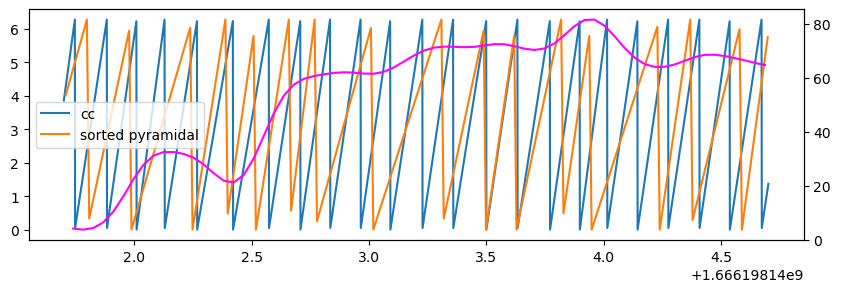

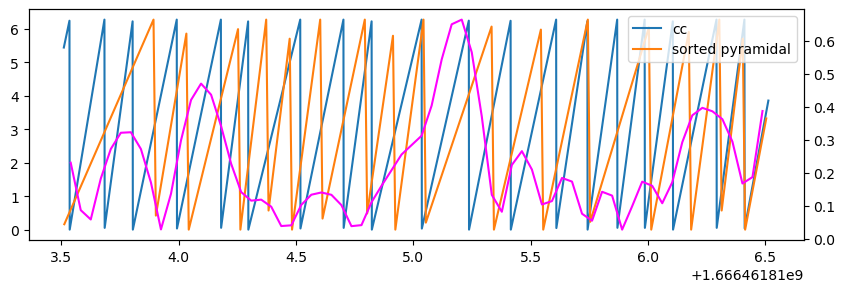

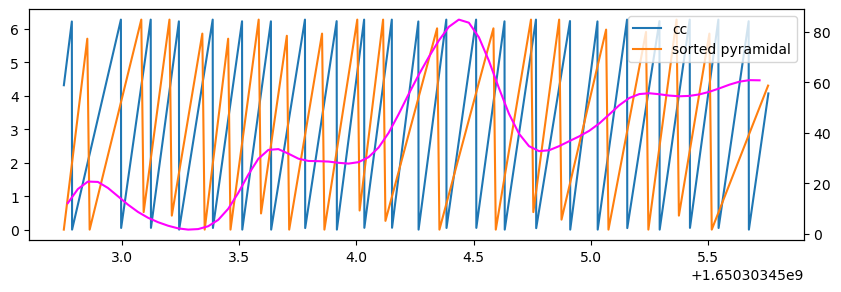

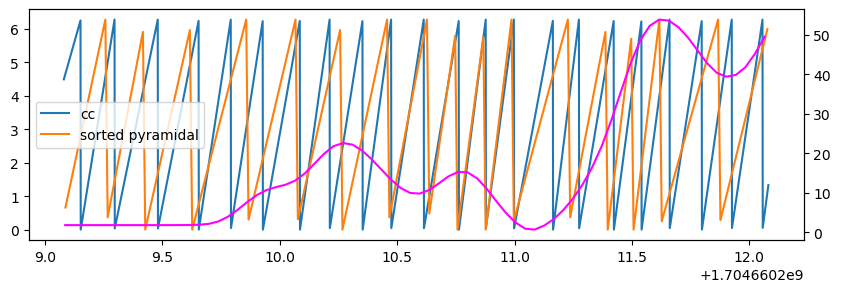

In [118]:
for animal in ['eliot','molly','lewis']:#sessions_to_plot.keys():
    for sessions in sessions_to_plot[animal]:
        _, d, session_name = sessions
        
        nwb_copy_file_name = f"{animal}{d}_.nwb"

        pos_name = session2position_name(nwb_copy_file_name, session_name)
        
        key_cc = {"nwb_file_name": nwb_copy_file_name,
                       "epoch": str(session_name[:2]),
                       "data_type":"corpus_callosum"}

        key_mua = {"nwb_file_name": nwb_copy_file_name,
                       "epoch": str(session_name[:2]),
                       "data_type":"sorted_pyramidal"}

        theta_cc = pd.read_csv((MUATheta() & key_cc).fetch1("theta_xr"))
        theta_mua = pd.read_csv((MUATheta() & key_mua).fetch1("theta_xr"))
        theta_cc.index = theta_cc.time
        theta_mua.index = theta_mua.time

        # Load state script
        key={'nwb_file_name':nwb_copy_file_name,'epoch':str(session_name[:2])}
        log_df = pd.DataFrame((TrialChoice & key).fetch1('choice_reward'))

        plottimes = (log_df.loc[10].timestamp_O+3, log_df.loc[10].timestamp_O+6)

        # Load running speed
        position_info = (IntervalPositionInfo() & {'nwb_file_name': nwb_copy_file_name,
                'interval_list_name': pos_name,
                'position_info_param_name': 'default'}).fetch1_dataframe()
        

        # subset
        theta_cc_subset = select_subset_helper_pd(theta_cc,plottimes)
        theta_mua_subset = select_subset_helper_pd(theta_mua,plottimes)
        speed_subset = select_subset_helper_pd(position_info,plottimes)

        # plot
        fig, axes = plt.subplots(1, 1, figsize = (10,3))
        
        axes.plot(theta_cc_subset.phase, color = 'C0', label = "cc")
        axes.plot(theta_mua_subset.phase, color = 'C1', label = "sorted pyramidal")
        ax2 = axes.twinx()
        
        ax2.plot(speed_subset.head_speed, color = 'magenta', label = 'animal speed')
        axes.legend()
        

In [111]:
pos_name